In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plt.style.use('ggplot')
# sns.set(rc=('figure.figure':(10,5)))

In [14]:
import os
os.getcwd()

'/home/yagasri100'

In [15]:
df=pd.read_csv(r"airlines_flights_data.csv")


In [16]:
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [17]:
# data exploratiom
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 19679 entries, 0 to 19678
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             19679 non-null  int64  
 1   airline           19679 non-null  str    
 2   flight            19679 non-null  str    
 3   source_city       19679 non-null  str    
 4   departure_time    19679 non-null  str    
 5   stops             19679 non-null  str    
 6   arrival_time      19679 non-null  str    
 7   destination_city  19679 non-null  str    
 8   class             19679 non-null  str    
 9   duration          19679 non-null  float64
 10  days_left         19679 non-null  int64  
 11  price             19679 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 1.8 MB


np.int64(0)

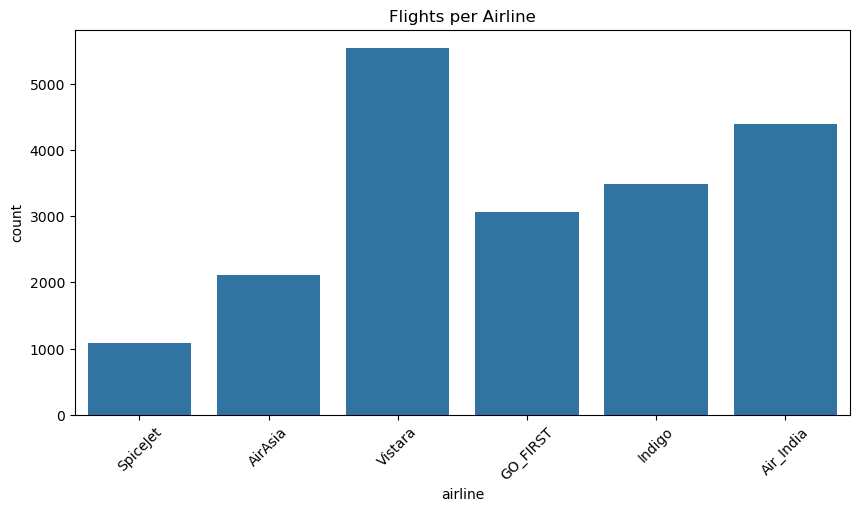

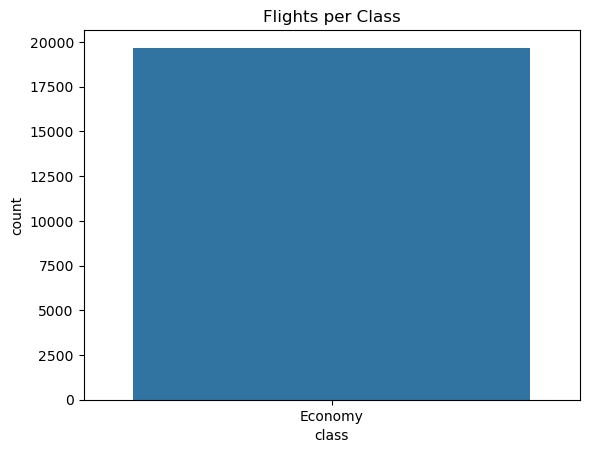

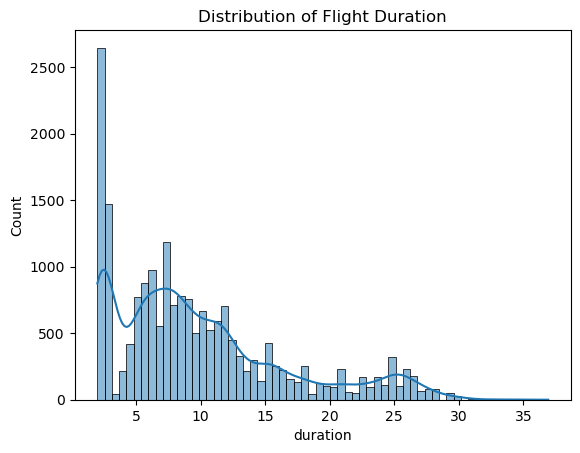

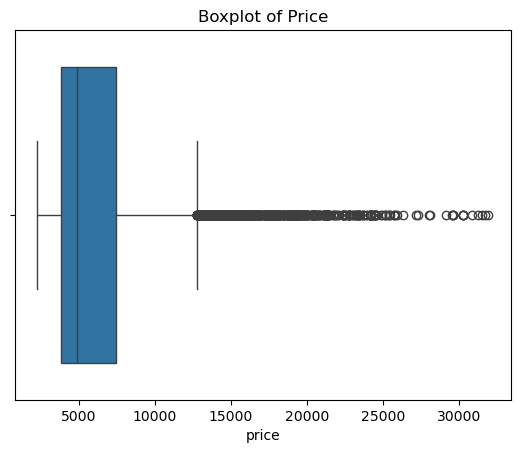

In [19]:
# Univariate Analysis
plt.figure(figsize=(10,5))
sns.countplot(x='airline', data=df)
plt.xticks(rotation=45)
plt.title('Flights per Airline')
plt.show()

sns.countplot(x='class', data=df)
plt.title('Flights per Class')
plt.show()

sns.histplot(df['duration'], kde=True)
plt.title('Distribution of Flight Duration')
plt.show()

sns.boxplot(x=df['price'])
plt.title('Boxplot of Price')
plt.show()

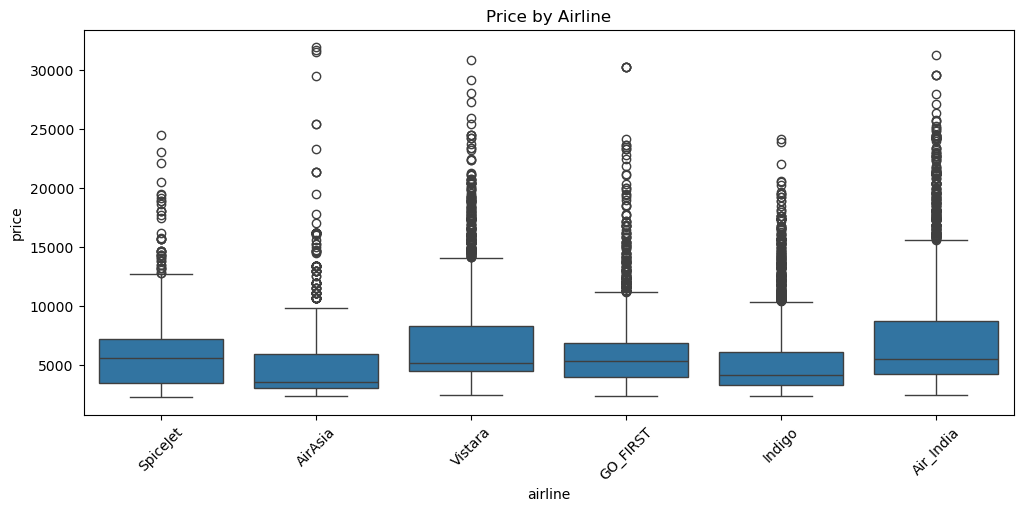

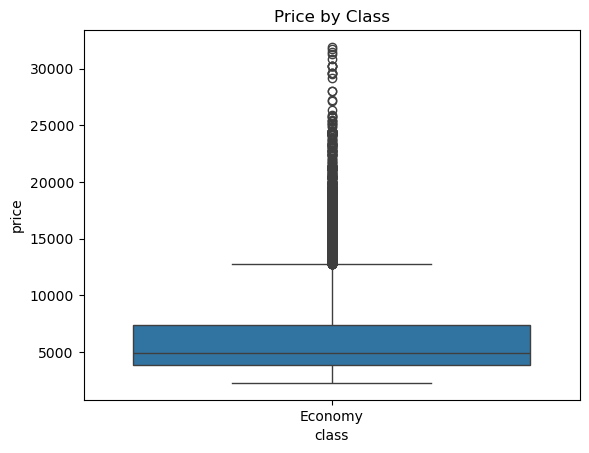

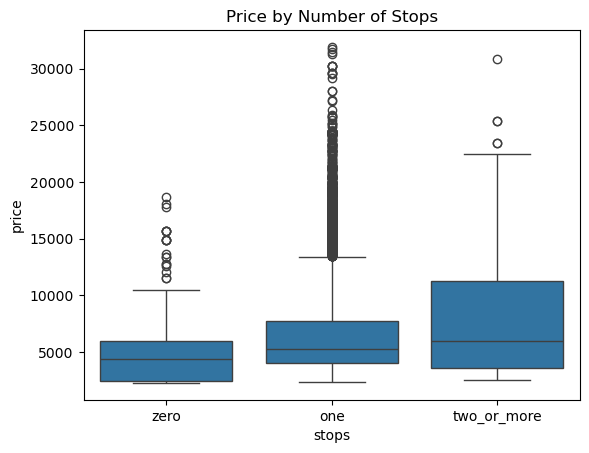

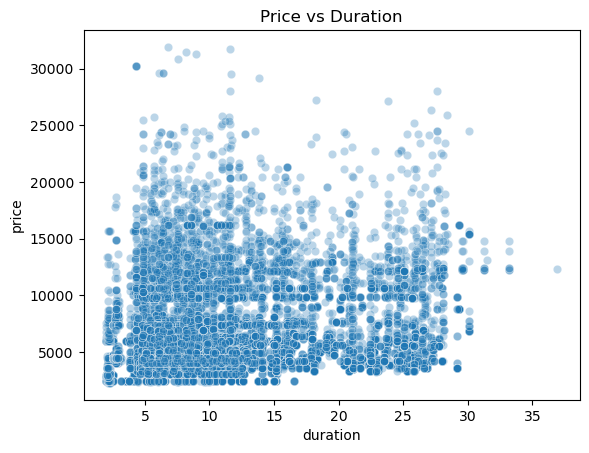

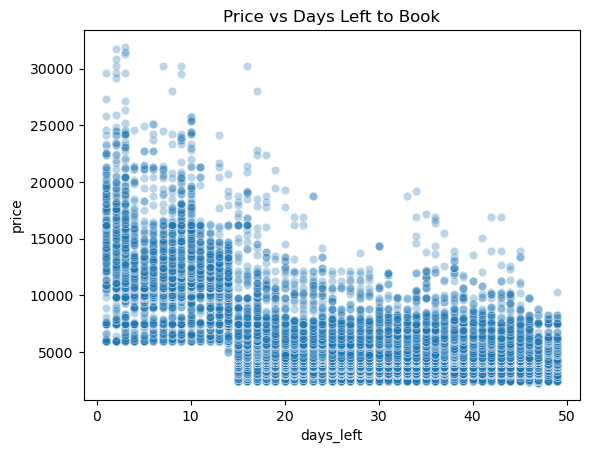

In [20]:
# Bivariate analysis

# 1. Price vs Airline
plt.figure(figsize=(12,5))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price by Airline')
plt.show()

# 2. Price vs Class
sns.boxplot(x='class', y='price', data=df)
plt.title('Price by Class')
plt.show()

# 3. Price vs Stops 
sns.boxplot(x='stops', y='price', data=df)
plt.title('Price by Number of Stops')
plt.show()

# 4. Price vs Duration - Scatter plot
sns.scatterplot(x='duration', y='price', data=df, alpha=0.3)
plt.title('Price vs Duration')
plt.show()

# 5. Price vs Days_left
sns.scatterplot(x='days_left', y='price', data=df, alpha=0.3)
plt.title('Price vs Days Left to Book')
plt.show()

              index   airline     stops  class  duration  days_left     price
index      1.000000 -0.048689 -0.096752    NaN  0.004660   0.471237 -0.259084
airline   -0.048689  1.000000  0.047068    NaN -0.068591  -0.032391  0.057474
stops     -0.096752  0.047068  1.000000    NaN -0.548273  -0.007342 -0.254720
class           NaN       NaN       NaN    NaN       NaN        NaN       NaN
duration   0.004660 -0.068591 -0.548273    NaN  1.000000  -0.056415  0.247001
days_left  0.471237 -0.032391 -0.007342    NaN -0.056415   1.000000 -0.581924
price     -0.259084  0.057474 -0.254720    NaN  0.247001  -0.581924  1.000000


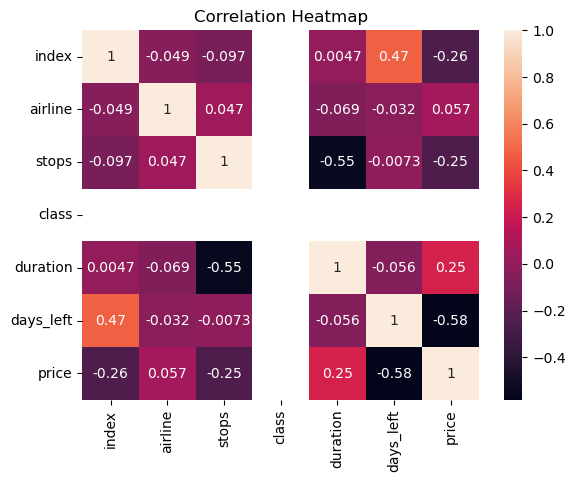

   index  airline   flight source_city departure_time  stops   arrival_time  \
0      0        4  SG-8709       Delhi        Evening      2          Night   
1      1        4  SG-8157       Delhi  Early_Morning      2        Morning   
2      2        0   I5-764       Delhi  Early_Morning      2  Early_Morning   
3      3        5   UK-995       Delhi        Morning      2      Afternoon   
4      4        5   UK-963       Delhi        Morning      2        Morning   

  destination_city  class  duration  days_left  price  price_per_day  \
0           Mumbai      0      2.17          1   5953         2976.5   
1           Mumbai      0      2.33          1   5953         2976.5   
2           Mumbai      0      2.17          1   5956         2978.0   
3           Mumbai      0      2.25          1   5955         2977.5   
4           Mumbai      0      2.33          1   5955         2977.5   

   long_flight  
0        False  
1        False  
2        False  
3        False  
4      

In [1]:
# Correlation and Feature Engineering
# Correlation heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("airlines_flights_data.csv")

# Encode categorical variables
df["airline"] = df["airline"].astype("category").cat.codes
df["class"] = df["class"].astype("category").cat.codes
df["stops"] = df["stops"].astype("category").cat.codes

# Select numerical columns
data = df.select_dtypes(include="number")

# Correlation
corr = data.corr()

print(corr)

# Heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Feature 1: Price per day left
df["price_per_day"] = df["price"] / (df["days_left"] + 1)

# Feature 2: Duration category
df["long_flight"] = df["duration"] > df["duration"].mean()

print(df.head())

In [23]:
# business insights
print("=== TOP 5 BUSINESS INSIGHTS ===")
print("1. Business class is 3-4x costlier than Economy")
print("2. Price increases as departure date approaches")
print("3. Direct flights cost more than connecting flights")
print("4. Longer duration = Higher price")
print("5. Economy has volume, Business has revenue")

print("\n=== 3 RECOMMENDATIONS ===")
print("1. Use dynamic pricing for last 7 days and direct flights")
print("2. Discount 1-stop flights to increase occupancy")
print("3. Launch premium business packages for corporate travelers")

=== TOP 5 BUSINESS INSIGHTS ===
1. Business class is 3-4x costlier than Economy
2. Price increases as departure date approaches
3. Direct flights cost more than connecting flights
4. Longer duration = Higher price
5. Economy has volume, Business has revenue

=== 3 RECOMMENDATIONS ===
1. Use dynamic pricing for last 7 days and direct flights
2. Discount 1-stop flights to increase occupancy
3. Launch premium business packages for corporate travelers
